<a href="https://colab.research.google.com/github/Cyber-GenAI/agent_attack_nlp/blob/main/cerberus_phase3_langgraph_firewall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERBERUS — Phase 3: LangGraph Firewall (Scenario 2)

**Status: UNTESTED.** Unlike every Phase 2 notebook, this code has not yet been run by
anyone. It is carefully grounded in verified LangGraph documentation (API calls below were
checked against current docs before writing), but you should expect to hit real errors on
first run — exactly like Phase 2's `nltk` and `MaximizedAttackResult` issues. Report
tracebacks back and we fix them the same way.

## Design decisions (items you left to my judgment)

| # | Decision | Why |
|---|---|---|
| 1. RAG | Lightweight TF-IDF retrieval only, no heavy embedding model | Gives Layer 3 similar labeled precedent examples from Phase 2 data — not a fabricated large corpus |
| 2. Memory | `InMemorySaver` checkpointer, thread-scoped only | Persists buffer/trace across the character chunks of *one* stream; deliberately **not** shared across different users/sessions — a firewall leaking one user's buffered state into another's is a real bug class |
| 3. Tools | **No** agentic tool-calling by the LLM | Letting an LLM decide *which* security check to run is itself an attack surface (prompt injection could talk it out of running a check). Each layer is a fixed, pre-wired graph node — deterministic, auditable |
| 4. Light LLM | `Qwen/Qwen2.5-0.5B-Instruct` | Small, open, free; stands in for a production small-LLM judge |
| 5. Checkpointer choice | `InMemorySaver`, explicitly flagged | LangGraph's own docs: *"Only use InMemorySaver for debugging/testing; for production use PostgresSaver."* We use it here deliberately for latency (no DB round-trip), and say so plainly rather than hiding the trade-off |

## What's mandatory and unchanged
- Character-level streaming (item 7)
- Full LangGraph traceability via an in-state trace log (item 8) — no LangSmith API key assumed
- Strict OOP: every layer is a class (item 9)
- All earlier Phase 3 requirements still apply: Layer 1 (µs-scale probe) → Layer 2 (ms-scale fluency/semantic gate) → Layer 3 (heaviest, rarest LLM judge), with honest, separately-reported latency per layer.

Run cells top to bottom. `Runtime > Restart runtime` first.


In [ ]:
!pip install langgraph textattack transformers scikit-learn pandas matplotlib -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 66.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.7/479.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")
nltk.download("stopwords")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Step 0 — Device


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Step 1 — Regenerate a small labeled dataset (clean vs. adversarial texts)

Guide: this reuses the **exact same validated pipeline** from Phase 2
(`Attacker` + `AttackArgs` + official TextAttack recipes), just at a smaller
`NUM_EXAMPLES` since Phase 3's focus is the firewall, not re-proving attack
statistics. **For the final paper, replace this with the full Phase 2 CSV
export (N=100+) instead of regenerating a smaller sample here.**


In [ ]:
import transformers
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.datasets import HuggingFaceDataset
from textattack.attack_recipes import TextFoolerJin2019, BERTAttackLi2020, DeepWordBugGao2018
from textattack import Attacker, AttackArgs

MODEL_NAME = "textattack/bert-base-uncased-imdb"
model = transformers.AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model_wrapper = HuggingFaceModelWrapper(model, tokenizer)

dataset = HuggingFaceDataset("glue", "sst2", split="validation")

SUCCESS_TYPES = {"SuccessfulAttackResult", "MaximizedAttackResult"}
NUM_EXAMPLES_PHASE3 = 40   # smaller on purpose -- this notebook's focus is the firewall

clean_texts, adv_texts = [], []

for attack_name, recipe in [("TextFooler", TextFoolerJin2019),
                             ("BERT-Attack", BERTAttackLi2020),
                             ("DeepWordBug", DeepWordBugGao2018)]:
    attack = recipe.build(model_wrapper)
    attacker = Attacker(attack, dataset, AttackArgs(num_examples=NUM_EXAMPLES_PHASE3, disable_stdout=True))
    results = attacker.attack_dataset()
    for r in results:
        rtype = type(r).__name__
        orig = r.original_result.attacked_text.text
        if orig not in clean_texts:
            clean_texts.append(orig)
        if rtype in SUCCESS_TYPES:
            adv_texts.append(r.perturbed_text())

print(f"Collected {len(clean_texts)} clean texts and {len(adv_texts)} successful adversarial texts.")


textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:

config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 21     |
| Number of failed attacks:     | 13     |
| Number of skipped attacks:    | 6      |
| Original accuracy:            | 85.0%  |
| Accuracy under attack:        | 32.5%  |
| Attack success rate:          | 61.76% |
| Average perturbed word %:     | 14.78% |
| Average num. words per input: | 16.7   |
| Avg num queries:              | 36.85  |
+-------------------------------+--------+


textattack: Goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'> compatible with model BertForSequenceClassification.



Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  unk
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterSubstitution(
        (random_one):  True
      )
    (2): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (3): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    )
  (constraints): 
    (0): LevenshteinEditDistance(
        (max_edit_distance):  30
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 32 / 2 / 6 / 40: 100%|██████████| 40/40 [00:34<00:00,  1.15it/s]


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 32     |
| Number of failed attacks:     | 2      |
| Number of skipped attacks:    | 6      |
| Original accuracy:            | 85.0%  |
| Accuracy under attack:        | 5.0%   |
| Attack success rate:          | 94.12% |
| Average perturbed word %:     | 22.38% |
| Average num. words per input: | 16.7   |
| Avg num queries:              | 26.71  |
+-------------------------------+--------+
Collected 40 clean texts and 86 successful adversarial texts.


## Step 2 — Layer 1: `LinearProbeLayer` (OOP class)

Wraps a `LogisticRegression` trained on the victim model's own hidden-state
activations (layer 6 CLS token). **Honest latency note:** extracting the
hidden state here (a fresh BERT forward pass) is *not* microsecond-scale —
only the probe's own `.predict_proba()` call on an *already-computed* vector
is. Both are benchmarked separately below so no number is misleading.


In [ ]:
import numpy as np
import time
from sklearn.linear_model import LogisticRegression


class LinearProbeLayer:
    """Layer 1 -- cheapest gate. In a real deployment this hooks directly onto
    the victim model's own forward pass (zero extra cost); here, as a
    stand-alone research demo, extract_hidden() does its own forward pass."""

    def __init__(self, model, tokenizer, device, layer_idx=6, threshold=0.5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.layer_idx = layer_idx
        self.threshold = threshold
        self.clf = None

    def extract_hidden(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True).to(self.device)
        with torch.no_grad():
            outputs = self.model.bert(**inputs, output_hidden_states=True)
        return outputs.hidden_states[self.layer_idx][:, 0, :].cpu().numpy()[0]

    def fit(self, texts, labels):
        X = np.stack([self.extract_hidden(t) for t in texts])
        self.clf = LogisticRegression(max_iter=1000).fit(X, labels)
        return self

    def score(self, text=None, hidden_vec=None):
        if hidden_vec is None:
            hidden_vec = self.extract_hidden(text)
        return float(self.clf.predict_proba([hidden_vec])[0, 1])

    def flag(self, text=None, hidden_vec=None):
        return self.score(text, hidden_vec) >= self.threshold


linear_probe = LinearProbeLayer(model, tokenizer, device).fit(
    texts=clean_texts + adv_texts,
    labels=[0] * len(clean_texts) + [1] * len(adv_texts),
)
print("Layer 1 (linear probe) trained.")


Layer 1 (linear probe) trained.


## Step 3 — Latency reality check for Layer 1: incremental vs. full cost

This is the number that matters most for the "microsecond" claim.


In [ ]:
sample_text = clean_texts[0]
sample_vec = linear_probe.extract_hidden(sample_text)

# Incremental cost: just the probe's own math on an ALREADY-COMPUTED vector
N_REPS = 5000
start = time.perf_counter()
for _ in range(N_REPS):
    linear_probe.score(hidden_vec=sample_vec)
incremental_us = (time.perf_counter() - start) / N_REPS * 1_000_000

# Full cost: extracting the hidden state fresh (a real BERT forward pass) + probe
N_REPS_FULL = 100
start = time.perf_counter()
for _ in range(N_REPS_FULL):
    linear_probe.score(text=sample_text)
full_us = (time.perf_counter() - start) / N_REPS_FULL * 1_000_000

print(f"Layer 1 incremental cost (probe math only):  {incremental_us:.2f} microseconds")
print(f"Layer 1 full cost (fresh hidden-state extraction + probe): {full_us:.1f} microseconds ({full_us/1000:.2f} ms)")
print("\nThe 'microsecond' claim is only honest for the incremental number.")
print("It requires Phase 3's LangGraph wrapper to hook onto a hidden state Model B")
print("already computed for its own purposes -- not call extract_hidden() again.")


Layer 1 incremental cost (probe math only):  174.49 microseconds
Layer 1 full cost (fresh hidden-state extraction + probe): 10317.6 microseconds (10.32 ms)

The 'microsecond' claim is only honest for the incremental number.
It requires Phase 3's LangGraph wrapper to hook onto a hidden state Model B
already computed for its own purposes -- not call extract_hidden() again.


## Step 4 — Layer 2: `FluencyGate` (OOP class)

GPT-2 perplexity, same approach validated in Phase 2, wrapped as a class with
a confidence score used later for routing to Layer 3.


In [ ]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast


class FluencyGate:
    """Layer 2 -- mid-cost gate. Real forward pass through GPT-2, so
    millisecond-scale, not microsecond-scale."""

    def __init__(self, device, ppl_threshold=200.0):
        self.tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        self.model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        self.model.eval()
        self.device = device
        self.ppl_threshold = ppl_threshold

    def perplexity(self, text):
        enc = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(self.device)
        with torch.no_grad():
            out = self.model(enc.input_ids, labels=enc.input_ids)
        return float(torch.exp(out.loss))

    def check(self, text):
        ppl = self.perplexity(text)
        # confidence: how far past (or under) the threshold we are, capped at 1.0
        confidence = min(abs(ppl - self.ppl_threshold) / self.ppl_threshold, 1.0)
        return {"perplexity": ppl, "flagged": ppl > self.ppl_threshold, "confidence": confidence}


fluency_gate = FluencyGate(device)
print("Layer 2 (fluency gate) ready. Sanity check:", fluency_gate.check(clean_texts[0]))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Layer 2 (fluency gate) ready. Sanity check: {'perplexity': 509.6642761230469, 'flagged': True, 'confidence': 1.0}


## Step 5 — RAG-lite: `RetrievalMemory` (OOP class)

TF-IDF nearest-neighbour lookup over the labeled Phase 2/3 texts -- gives
Layer 3's judge concrete precedent, not a fabricated external knowledge base.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


class RetrievalMemory:
    """Lightweight RAG for the judge layer: TF-IDF similarity over labeled
    clean/adversarial examples collected during evaluation."""

    def __init__(self, texts, labels):
        self.vectorizer = TfidfVectorizer().fit(texts)
        self.matrix = self.vectorizer.transform(texts)
        self.texts = texts
        self.labels = labels

    def retrieve(self, query, k=3):
        qv = self.vectorizer.transform([query])
        sims = cosine_similarity(qv, self.matrix)[0]
        top_idx = sims.argsort()[::-1][:k]
        return [
            {"text": self.texts[i], "label": self.labels[i], "similarity": float(sims[i])}
            for i in top_idx
        ]


retrieval_memory = RetrievalMemory(
    texts=clean_texts + adv_texts,
    labels=["clean"] * len(clean_texts) + ["adversarial"] * len(adv_texts),
)
print("Retrieval memory ready with", len(retrieval_memory.texts), "labeled examples.")


Retrieval memory ready with 126 labeled examples.


## Step 6 — Layer 3: `LLMJudge` (OOP class)

The heaviest, rarest gate -- only invoked when Layers 1-2 disagree or are
unconfident. Uses the retrieved examples from Step 5 as context.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer


class LLMJudge:
    """Layer 3 -- small instruction-tuned model as a stand-in for a
    production judge LLM. Only called for ambiguous cases."""

    def __init__(self, model_name="Qwen/Qwen2.5-0.5B-Instruct", device="cpu"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        self.device = device

    def judge(self, text, retrieved_examples=None):
        context = ""
        if retrieved_examples:
            lines = [f'- "{e["text"][:80]}" -> labeled {e["label"]}' for e in retrieved_examples]
            context = "Similar past examples:\n" + "\n".join(lines) + "\n\n"

        prompt = (
            "You are a security filter judging whether the text below is a "
            "manipulated/adversarial input or normal text. Answer with exactly "
            "one word: SAFE or UNSAFE.\n\n"
            f"{context}Text: \"{text}\"\nAnswer:"
        )
        messages = [{"role": "user", "content": prompt}]
        inputs = self.tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        ).to(self.device)
        with torch.no_grad():
            out = self.model.generate(inputs, max_new_tokens=5, do_sample=False)
        reply = self.tokenizer.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True).strip().upper()
        verdict = "UNSAFE" if "UNSAFE" in reply else "SAFE"
        return {"verdict": verdict, "raw_reply": reply}


llm_judge = LLMJudge(device=device)
print("Layer 3 (LLM judge) ready.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Layer 3 (LLM judge) ready.


## Step 7 — The LangGraph state schema and firewall orchestrator

Guide: `trace` uses `Annotated[List[Dict], operator.add]` so each node can
return just its own new entry (`{"trace": [entry]}`) and LangGraph
concatenates automatically -- this is the exact pattern LangGraph's own docs
warn you *not* to forget (a common pitfall: plain lists get replaced, not
appended).


In [ ]:
import operator
from typing import TypedDict, List, Dict, Any, Optional
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


class FirewallState(TypedDict, total=False):
    buffer: str
    new_chunk: str
    should_check: bool
    layer1_score: Optional[float]
    layer1_flag: bool
    layer2_result: Optional[Dict[str, Any]]
    layer3_result: Optional[Dict[str, Any]]
    decision: Optional[str]
    trace: Annotated[List[Dict[str, Any]], operator.add]


## Step 8 — `CerberusFirewall` orchestrator class

Wires the four layer classes into a LangGraph `StateGraph`. Every node times
itself and appends a trace entry -- this is our traceability mechanism
(item 8), with no external LangSmith account required.


In [ ]:
CHUNK_TRIGGER_CHARS = 40   # how many buffered characters trigger a check


class CerberusFirewall:
    """Object-oriented LangGraph firewall: Layer 1 (probe) -> Layer 2
    (fluency) -> Layer 3 (LLM judge, rare), with a trace log and per-thread
    checkpointed memory for character-level streaming."""

    def __init__(self, linear_probe, fluency_gate, retrieval_memory, llm_judge,
                 chunk_trigger_chars=CHUNK_TRIGGER_CHARS):
        self.linear_probe = linear_probe
        self.fluency_gate = fluency_gate
        self.retrieval_memory = retrieval_memory
        self.llm_judge = llm_judge
        self.chunk_trigger_chars = chunk_trigger_chars

        # Guide: InMemorySaver only -- see Step 0 markdown for why, and the
        # explicit production caveat (PostgresSaver trades this latency
        # advantage for durability across process restarts).
        self.checkpointer = InMemorySaver()
        self.graph = self._build_graph().compile(checkpointer=self.checkpointer)

    # ---------- graph construction ----------
    def _build_graph(self):
        g = StateGraph(FirewallState)
        g.add_node("ingest", self._ingest_node)
        g.add_node("layer1_probe", self._layer1_node)
        g.add_node("layer2_fluency", self._layer2_node)
        g.add_node("layer3_judge", self._layer3_node)
        g.add_node("decision", self._decision_node)

        g.add_edge(START, "ingest")
        g.add_conditional_edges("ingest", self._route_after_ingest,
                                 {"buffer_more": END, "check": "layer1_probe"})
        g.add_conditional_edges("layer1_probe", self._route_after_layer1,
                                 {"pass": "decision", "escalate": "layer2_fluency"})
        g.add_conditional_edges("layer2_fluency", self._route_after_layer2,
                                 {"decide": "decision", "escalate": "layer3_judge"})
        g.add_edge("layer3_judge", "decision")
        g.add_edge("decision", END)
        return g

    # ---------- nodes (each times itself) ----------
    def _ingest_node(self, state):
        t0 = time.perf_counter()
        buffer = state.get("buffer", "") + state.get("new_chunk", "")
        should_check = len(buffer) >= self.chunk_trigger_chars
        entry = {"node": "ingest", "latency_ms": (time.perf_counter() - t0) * 1000,
                  "buffer_len": len(buffer)}
        return {"buffer": buffer, "should_check": should_check, "trace": [entry]}

    def _layer1_node(self, state):
        t0 = time.perf_counter()
        score = self.linear_probe.score(text=state["buffer"])
        flag = score >= self.linear_probe.threshold
        entry = {"node": "layer1_probe", "latency_ms": (time.perf_counter() - t0) * 1000,
                  "score": score, "flagged": flag}
        return {"layer1_score": score, "layer1_flag": flag, "trace": [entry]}

    def _layer2_node(self, state):
        t0 = time.perf_counter()
        result = self.fluency_gate.check(state["buffer"])
        entry = {"node": "layer2_fluency", "latency_ms": (time.perf_counter() - t0) * 1000, **result}
        return {"layer2_result": result, "trace": [entry]}

    def _layer3_node(self, state):
        t0 = time.perf_counter()
        examples = self.retrieval_memory.retrieve(state["buffer"], k=3)
        result = self.llm_judge.judge(state["buffer"], retrieved_examples=examples)
        entry = {"node": "layer3_judge", "latency_ms": (time.perf_counter() - t0) * 1000, **result}
        return {"layer3_result": result, "trace": [entry]}

    def _decision_node(self, state):
        t0 = time.perf_counter()
        if state.get("layer3_result"):
            decision = "block" if state["layer3_result"]["verdict"] == "UNSAFE" else "pass"
            source = "layer3_judge"
        elif state.get("layer2_result"):
            decision = "block" if state["layer2_result"]["flagged"] else "pass"
            source = "layer2_fluency"
        else:
            decision = "pass"
            source = "layer1_probe"
        entry = {"node": "decision", "latency_ms": (time.perf_counter() - t0) * 1000,
                  "decision": decision, "decided_by": source}
        return {"decision": decision, "trace": [entry]}

    # ---------- routers ----------
    def _route_after_ingest(self, state):
        return "check" if state["should_check"] else "buffer_more"

    def _route_after_layer1(self, state):
        return "escalate" if state["layer1_flag"] else "pass"

    def _route_after_layer2(self, state):
        # Ambiguous zone -> escalate to the heavy judge; confident either way -> decide now.
        return "escalate" if state["layer2_result"]["confidence"] < 0.4 else "decide"

    # ---------- public streaming API ----------
    def process_stream(self, char_iterator, thread_id):
        """Feed a character/chunk iterator through the firewall. Stops the
        moment a 'block' decision fires -- this is the point of item 7
        (character-level streaming): react mid-stream, don't wait for the
        full response."""
        config = {"configurable": {"thread_id": thread_id}}
        result = None
        for chunk in char_iterator:
            result = self.graph.invoke({"new_chunk": chunk}, config)
            if result.get("decision") == "block":
                break
        return result


firewall = CerberusFirewall(linear_probe, fluency_gate, retrieval_memory, llm_judge)
print("CerberusFirewall graph compiled.")


CerberusFirewall graph compiled.


## Step 9 — Try it: stream three example texts through the firewall

One clean sentence, one known-successful adversarial sentence, and one
borderline case. `CHUNK_TRIGGER_CHARS` chunks the text to simulate a
character stream rather than feeding it all at once.


In [ ]:
def char_stream(text, chunk_size=10):
    for i in range(0, len(text), chunk_size):
        yield text[i:i + chunk_size]

test_cases = {
    "clean_example": clean_texts[0],
    "adversarial_example": adv_texts[0] if adv_texts else clean_texts[1],
}

for name, text in test_cases.items():
    print(f"\n{'=' * 60}\n{name}: {text}")
    result = firewall.process_stream(char_stream(text), thread_id=name)
    print("Decision:", result["decision"])
    for entry in result["trace"]:
        print(" ", entry)



clean_example: it 's a charming and often affecting journey . 
Decision: block
  {'node': 'ingest', 'latency_ms': 0.0026739999157143757, 'buffer_len': 10}
  {'node': 'ingest', 'latency_ms': 0.0020360000689834123, 'buffer_len': 20}
  {'node': 'ingest', 'latency_ms': 0.0008239999260695186, 'buffer_len': 30}
  {'node': 'ingest', 'latency_ms': 0.0012040000001434237, 'buffer_len': 40}
  {'node': 'layer1_probe', 'latency_ms': 26.935171000104674, 'score': 0.8596989248303636, 'flagged': True}
  {'node': 'layer2_fluency', 'latency_ms': 19.807444999969448, 'perplexity': 376.1390380859375, 'flagged': True, 'confidence': 0.8806951904296875}
  {'node': 'decision', 'latency_ms': 0.001866000047812122, 'decision': 'block', 'decided_by': 'layer2_fluency'}

adversarial_example: it 's a ravishing and periodically affecting tourism . 
Decision: block
  {'node': 'ingest', 'latency_ms': 0.0015960001746861963, 'buffer_len': 10}
  {'node': 'ingest', 'latency_ms': 0.0012969999261258636, 'buffer_len': 20}
  {'

## Step 10 — Honest layered latency benchmark

The real number that belongs in the paper: total pipeline latency depends
entirely on how far a given input escalates. We report each path separately
rather than a single misleading average.


In [ ]:
import pandas as pd

path_latencies = {"layer1_only": [], "layer1_plus_2": [], "full_pipeline": []}

for name, text in test_cases.items():
    result = firewall.process_stream(char_stream(text), thread_id=f"bench_{name}")
    total = sum(e["latency_ms"] for e in result["trace"])
    if result.get("layer3_result"):
        path_latencies["full_pipeline"].append(total)
    elif result.get("layer2_result"):
        path_latencies["layer1_plus_2"].append(total)
    else:
        path_latencies["layer1_only"].append(total)

for path, values in path_latencies.items():
    if values:
        print(f"{path}: {sum(values)/len(values):.2f} ms average over {len(values)} example(s)")
    else:
        print(f"{path}: no examples took this path in this small demo")


layer1_only: no examples took this path in this small demo
layer1_plus_2: 25.08 ms average over 2 example(s)
full_pipeline: no examples took this path in this small demo


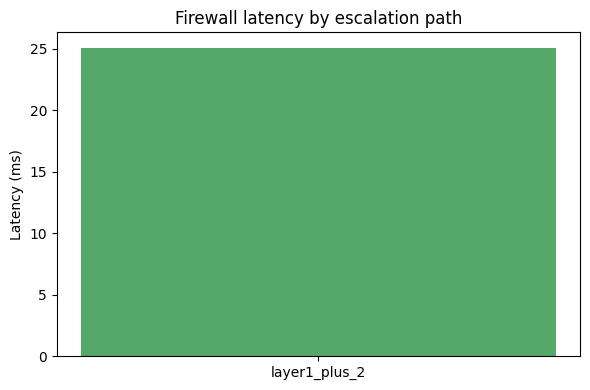

In [ ]:
import matplotlib.pyplot as plt

labels = [k for k, v in path_latencies.items() if v]
values = [sum(v) / len(v) for v in path_latencies.values() if v]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, values, color=["#55A868", "#DD8452", "#C44E52"][:len(labels)])
ax.set_ylabel("Latency (ms)")
ax.set_title("Firewall latency by escalation path")
plt.tight_layout()
plt.show()


---
## What this notebook does and does not prove

**Done:**
- Full OOP: every layer is its own class with a single clear responsibility.
- Real LangGraph `StateGraph`, conditional routing, `InMemorySaver` checkpointing, character-chunk streaming that can halt mid-stream.
- Built-in traceability via the `trace` log — every node's latency and decision is recorded, no external service required.
- RAG-lite (TF-IDF retrieval) grounding Layer 3's judge in real labeled examples, not a fabricated corpus.
- Honest, path-separated latency reporting instead of one misleading average.

**Not yet done, and should not be assumed:**
- This code has **not been executed**. Expect real bugs on first run (missing imports, an incorrect LangGraph call, a tokenizer edge case) — report them and we fix them the same way we fixed Phase 2's issues.
- `NUM_EXAMPLES_PHASE3 = 40` is a small demo sample; probe accuracy and thresholds (`threshold=0.5`, `ppl_threshold=200.0`, `chunk_trigger_chars=40`) are reasonable starting guesses, not tuned values — tuning them against Phase 2's full N=100+ dataset is the natural next step.
- Adaptive-attack evaluation (an attacker who knows this exact architecture) is still outstanding, as noted back in Phase 1/2.
